# Generative AI — Part 1

## Topics Covered

 -What is Generative AI?

 -Overview of Generative Models

 Generative Adversarial Networks (GANs)

 Variational Autoencoders (VAEs)

 Image Synthesis with GANs

 Text Generation with GPT

## Practical Work

- Build a GAN using TensorFlow/Keras
- Generate synthetic MNIST images
- Understand Generator and Discriminator
- Build a simple VAE
- Generate images from latent space
- Generate text using a pretrained GPT-style model

# Major Generative Models

GANs
→ Generator + Discriminator
→ Commonly used for image generation

VAEs
→ Encoder + Latent Space + Decoder
→ Used for generation and representation learning

LLMs
→ Transformer-based language models
→ Used mainly for text and code generation

Diffusion Models
→ Gradually transform noise into structured data
→ Widely used for modern image generation

#GAN

# Generative Adversarial Network

A GAN contains two neural networks:

1. Generator
2. Discriminator

Generator:
Creates fake samples.

Discriminator:
Tries to identify whether a sample is real or fake.

Training:

Random Noise
     ↓
Generator
     ↓
Fake Image
     ↓
Discriminator
     ↑
Real Image

The Generator tries to fool the Discriminator.
The Discriminator tries to correctly identify fake samples.

#Install Libraries

In [1]:
!pip install -q tensorflow matplotlib

#Import Libraries

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import layers

#Load MNIST

In [3]:
(X_train, y_train), (_, _) = tf.keras.datasets.mnist.load_data()

print("Shape:", X_train.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Shape: (60000, 28, 28)


##Preprocess Data

In [4]:
X_train = X_train.astype("float32")

# Convert [0, 255] → [-1, 1]
X_train = (X_train - 127.5) / 127.5

# Add channel dimension
X_train = np.expand_dims(X_train, axis=-1)

print(X_train.shape)

(60000, 28, 28, 1)


#Create Dataset

In [5]:
BUFFER_SIZE = 60000
BATCH_SIZE = 256

train_dataset = (
    tf.data.Dataset
    .from_tensor_slices(X_train)
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE)
)

# Generator

The Generator receives random noise and converts it into an image.

Random Noise
     ↓
Dense Layer
     ↓
Reshape
     ↓
Transposed Convolution
     ↓
Transposed Convolution
     ↓
Generated Image

In [6]:
latent_dim = 100

generator = tf.keras.Sequential([

    layers.Dense(
        7 * 7 * 256,
        use_bias=False,
        input_shape=(latent_dim,)
    ),

    layers.BatchNormalization(),
    layers.LeakyReLU(),

    layers.Reshape((7, 7, 256)),

    layers.Conv2DTranspose(
        128,
        kernel_size=5,
        strides=1,
        padding="same",
        use_bias=False
    ),

    layers.BatchNormalization(),
    layers.LeakyReLU(),

    layers.Conv2DTranspose(
        64,
        kernel_size=5,
        strides=2,
        padding="same",
        use_bias=False
    ),

    layers.BatchNormalization(),
    layers.LeakyReLU(),

    layers.Conv2DTranspose(
        1,
        kernel_size=5,
        strides=2,
        padding="same",
        activation="tanh"
    )
])

generator.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 128)      │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │         1,601 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,945 (8.89 MB)

 Trainable params: 2,305,473 (8.79 MB)

 Non-trainable params: 25,472 (99.50 KB)

#Test Generator

In [7]:
noise = tf.random.normal([1, latent_dim])

generated_image = generator(
    noise,
    training=False
)

print(generated_image.shape)

(1, 28, 28, 1)


# Discriminator

The Discriminator receives an image and predicts whether it is real
or generated.

Image
 ↓
Convolution
 ↓
LeakyReLU
 ↓
Dropout
 ↓
Convolution
 ↓
Flatten
 ↓
Dense
 ↓
Real / Fake

In [8]:
discriminator = tf.keras.Sequential([

    layers.Conv2D(
        64,
        kernel_size=5,
        strides=2,
        padding="same",
        input_shape=[28, 28, 1]
    ),

    layers.LeakyReLU(),
    layers.Dropout(0.3),

    layers.Conv2D(
        128,
        kernel_size=5,
        strides=2,
        padding="same"
    ),

    layers.LeakyReLU(),
    layers.Dropout(0.3),

    layers.Flatten(),

    layers.Dense(1)
])

discriminator.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

# GAN Loss

Discriminator:

Real image → 1
Fake image → 0

Generator:

Fake image → Discriminator should predict 1

Therefore:

Generator → tries to fool Discriminator

Discriminator → tries to distinguish real and fake

In [9]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(
    from_logits=True
)

In [10]:
def generator_loss(fake_output):

    return cross_entropy(
        tf.ones_like(fake_output),
        fake_output
    )

In [11]:
def discriminator_loss(real_output, fake_output):

    real_loss = cross_entropy(
        tf.ones_like(real_output),
        real_output
    )

    fake_loss = cross_entropy(
        tf.zeros_like(fake_output),
        fake_output
    )

    return real_loss + fake_loss

#Optimizers

In [12]:
generator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=1e-4
)

discriminator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=1e-4
)

#GAN Training

In [13]:
@tf.function
def train_step(images):

    noise = tf.random.normal(
        [BATCH_SIZE, latent_dim]
    )

    with tf.GradientTape() as gen_tape, \
         tf.GradientTape() as disc_tape:

        generated_images = generator(
            noise,
            training=True
        )

        real_output = discriminator(
            images,
            training=True
        )

        fake_output = discriminator(
            generated_images,
            training=True
        )

        gen_loss = generator_loss(
            fake_output
        )

        disc_loss = discriminator_loss(
            real_output,
            fake_output
        )

    gradients_gen = gen_tape.gradient(
        gen_loss,
        generator.trainable_variables
    )

    gradients_disc = disc_tape.gradient(
        disc_loss,
        discriminator.trainable_variables
    )

    generator_optimizer.apply_gradients(
        zip(
            gradients_gen,
            generator.trainable_variables
        )
    )

    discriminator_optimizer.apply_gradients(
        zip(
            gradients_disc,
            discriminator.trainable_variables
        )
    )

    return gen_loss, disc_loss

#Train GAN

In [14]:
EPOCHS = 20

for epoch in range(EPOCHS):

    for image_batch in train_dataset:

        gen_loss, disc_loss = train_step(
            image_batch
        )

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Generator Loss: {gen_loss:.4f} | "
        f"Discriminator Loss: {disc_loss:.4f}"
    )

Epoch 1/20 | Generator Loss: 0.8111 | Discriminator Loss: 1.1334
Epoch 2/20 | Generator Loss: 1.2228 | Discriminator Loss: 0.7793
Epoch 3/20 | Generator Loss: 0.8703 | Discriminator Loss: 1.1975
Epoch 4/20 | Generator Loss: 0.7484 | Discriminator Loss: 1.4618
Epoch 5/20 | Generator Loss: 0.7812 | Discriminator Loss: 1.5383
Epoch 6/20 | Generator Loss: 0.8914 | Discriminator Loss: 1.2513
Epoch 7/20 | Generator Loss: 0.9972 | Discriminator Loss: 1.0452
Epoch 8/20 | Generator Loss: 0.9511 | Discriminator Loss: 1.0439
Epoch 9/20 | Generator Loss: 0.8029 | Discriminator Loss: 1.5282
Epoch 10/20 | Generator Loss: 0.7771 | Discriminator Loss: 1.3725
Epoch 11/20 | Generator Loss: 1.1688 | Discriminator Loss: 0.8894
Epoch 12/20 | Generator Loss: 0.9339 | Discriminator Loss: 1.2992
Epoch 13/20 | Generator Loss: 0.9238 | Discriminator Loss: 1.2955
Epoch 14/20 | Generator Loss: 0.9979 | Discriminator Loss: 1.1631
Epoch 15/20 | Generator Loss: 1.2190 | Discriminator Loss: 0.9031
Epoch 16/20 | Gener

# Image Synthesis Using GAN

After training, we provide random noise to the Generator.

The Generator produces a new image.

In [15]:
noise = tf.random.normal(
    [16, latent_dim]
)

generated_images = generator(
    noise,
    training=False
)

generated_images = (
    generated_images + 1
) / 2

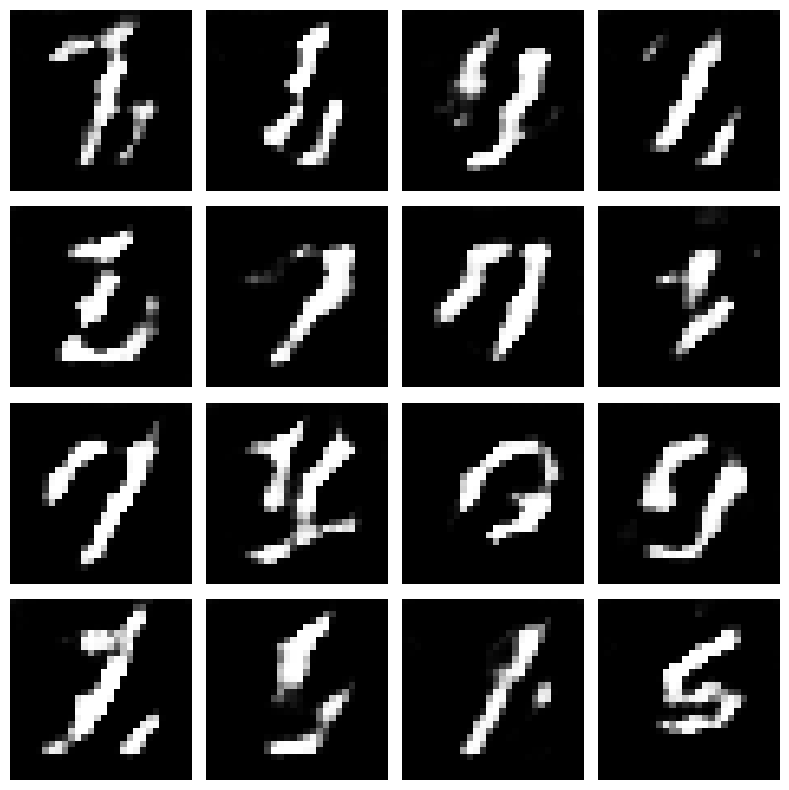

In [16]:
plt.figure(figsize=(8, 8))

for i in range(16):

    plt.subplot(4, 4, i + 1)

    plt.imshow(
        generated_images[i, :, :, 0],
        cmap="gray"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

# Common GAN Problems

Mode Collapse:
The Generator produces very similar samples.

Training Instability:
Generator and Discriminator may not improve at the same rate.

Vanishing Gradients:
The Generator may receive weak learning signals.

Evaluation:
Image quality cannot be completely measured using accuracy.

# Variational Autoencoder

A VAE consists of:

Encoder
    ↓
Latent Distribution
    ↓
Decoder

Unlike a basic Autoencoder, the VAE learns a probabilistic latent
representation.

The latent representation can then be sampled to generate new data.

#Load MNIST

In [17]:
(X_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

X_train = X_train.astype("float32") / 255.0

X_train = X_train.reshape(
    -1,
    784
)

print(X_train.shape)

(60000, 784)


#. Encoder

In [18]:
latent_dim = 2

encoder_inputs = tf.keras.Input(
    shape=(784,)
)

x = layers.Dense(
    256,
    activation="relu"
)(encoder_inputs)

x = layers.Dense(
    128,
    activation="relu"
)(x)

z_mean = layers.Dense(
    latent_dim,
    name="z_mean"
)(x)

z_log_var = layers.Dense(
    latent_dim,
    name="z_log_var"
)(x)

# Reparameterization Trick

The Encoder produces:

Mean → μ
Log Variance → log(σ²)

We sample:

z = μ + σ × ε

where:

ε ~ N(0, 1)

This allows the VAE to remain trainable using backpropagation.

In [19]:
def sampling(args):

    z_mean, z_log_var = args

    epsilon = tf.random.normal(
        shape=tf.shape(z_mean)
    )

    return (
        z_mean +
        tf.exp(0.5 * z_log_var) *
        epsilon
    )

z = layers.Lambda(
    sampling,
    name="sampling"
)([z_mean, z_log_var])

#Decoder

In [20]:
decoder_input = tf.keras.Input(
    shape=(latent_dim,)
)

x = layers.Dense(
    128,
    activation="relu"
)(decoder_input)

x = layers.Dense(
    256,
    activation="relu"
)(x)

decoder_output = layers.Dense(
    784,
    activation="sigmoid"
)(x)

decoder = tf.keras.Model(
    decoder_input,
    decoder_output,
    name="decoder"
)

#Build VAE

In [21]:
encoder = tf.keras.Model(
    encoder_inputs,
    [z_mean, z_log_var, z],
    name="encoder"
)

vae_output = decoder(z)

vae = tf.keras.Model(
    encoder_inputs,
    vae_output,
    name="vae"
)

vae.summary()

Model: "vae"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    200,960 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │     32,896 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │        258 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │        258 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Lambda)   │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder             │ (None, 784)       │    234,896 │ sampling[0][0]    │
│ (Functional)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 469,268 (1.79 MB)

 Trainable params: 469,268 (1.79 MB)

 Non-trainable params: 0 (0.00 B)

# VAE Loss

VAE uses two main losses:

1. Reconstruction Loss
2. KL Divergence

Total Loss:

VAE Loss =
Reconstruction Loss + KL Divergence

Reconstruction Loss:
Measures how well the output reconstructs the input.

KL Divergence:
Regularizes the latent distribution.

# Text Generation with GPT

GPT-style models generate text autoregressively.

Example:

Input:
"Artificial intelligence is"

        ↓

Next token

"changing"

        ↓

"Artificial intelligence is changing"

        ↓

Next token

"the"

        ↓

"Artificial intelligence is changing the..."

#Install Transformers

In [22]:
!pip install -q transformers torch accelerate

#Load a Text Generation Pipeline

In [23]:
from transformers import pipeline

generator = pipeline(
    "text-generation",
    model="distilgpt2"
)

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  353MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

#Generate Text

In [24]:
prompt = "Artificial intelligence will"

result = generator(
    prompt,
    max_new_tokens=50,
    num_return_sequences=1
)

print(result[0]["generated_text"])

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'num_return_sequences'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=50) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Artificial intelligence will be able to perform many of the tasks that humans want to do, such as in computer science. But the work is limited to areas of computational science that humans need more than humans, and that does not mean that humans are capable of doing things that


#Experiment with Temperature

In [25]:
prompt = "The future of artificial intelligence is"

for temperature in [0.2, 0.7, 1.2]:

    result = generator(
        prompt,
        max_new_tokens=40,
        temperature=temperature,
        do_sample=True
    )

    print("=" * 70)
    print("Temperature:", temperature)
    print(result[0]["generated_text"])

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'do_sample', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=40) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=40) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Temperature: 0.2
The future of artificial intelligence is not a question of whether it is a good idea to develop artificial intelligence. But it is a question of whether it is a good idea to develop artificial intelligence.










[transformers] Both `max_new_tokens` (=40) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Temperature: 0.7
The future of artificial intelligence is not really about it. It's about helping people learn more about how to interact with their human counterparts and how to deal with this complexity without getting too involved with the world. Instead, we need to
Temperature: 1.2
The future of artificial intelligence is a complex, interconnected task that goes beyond just the search and investigation of the Internet, and is particularly important given the complexity of it: artificial intelligence technology may be the biggest challenge currently facing society in this


# Important Generation Parameters

max_new_tokens:
Controls how many new tokens are generated.

temperature:
Controls randomness during generation.

Lower temperature:
More predictable output.

Higher temperature:
More varied output.

top_k:
Limits sampling to the k most likely tokens.

top_p:
Controls sampling using cumulative probability.

# Part 1 Summary

In Part 1 we covered:

- Generative AI
- Generative Models
- GANs
- Generator
- Discriminator
- GAN Training
- GAN Image Synthesis
- Mode Collapse
- VAEs
- Encoder
- Latent Space
- Reparameterization
- Decoder
- GPT-style Text Generation
- Temperature

Practical implementations:

1. GAN on MNIST
2. Image generation using GAN
3. VAE architecture
4. Text generation using GPT-style model

# Generative AI & LLM — Part 2

## Topics Covered

54. Introduction to Large Language Models
55. Transformers and Attention Mechanism
56. Evolution of LLMs — GPT, BERT, T5
57. Hugging Face Transformers
58. Loading a Pre-trained LLM

## Practical Work

- Understand tokenization
- Explore attention
- Use Hugging Face pipelines
- Perform sentiment analysis
- Generate text
- Load a tokenizer
- Load a pretrained causal language model
- Generate text using model.generate()

# Large Language Models

LLMs are large neural networks trained on very large collections
of text.

They learn patterns in:

- Language
- Grammar
- Context
- Relationships between words
- Sentence structure
- Code

Common applications:

- Text generation
- Question answering
- Summarization
- Translation
- Classification
- Code generation
- Information extraction

# LLM Pipeline

Large Text Dataset
       ↓
Tokenization
       ↓
Token IDs
       ↓
Transformer
       ↓
Pretraining
       ↓
Pretrained LLM
       ↓
Fine-tuning / Instruction Tuning
       ↓
Application

# 22. Transformers

Transformers are neural network architectures built around
attention mechanisms.

They became the foundation of many modern NLP systems and LLMs.

A simplified Transformer:

Input Tokens
     ↓
Token Embeddings
     ↓
Attention
     ↓
Feed Forward Network
     ↓
Output

# 23. Attention Mechanism

Attention allows a model to determine which tokens are important
when processing another token.

Example:

"The animal didn't cross the road because it was tired."

To understand "it", the model needs information from the context.

Attention helps the model model relationships between tokens.

# 24. Query, Key and Value

Query (Q)
→ What information am I looking for?

Key (K)
→ What information does each token provide?

Value (V)
→ What information should be passed forward?

Attention:

Q × Kᵀ
   ↓
Similarity Scores
   ↓
Softmax
   ↓
Attention Weights
   ↓
Weighted Values
   ↓
Output

# Scaled Dot-Product Attention

Attention(Q, K, V)
=
softmax(
    QKᵀ / √dₖ
) V

# 25. Multi-Head Attention

Transformers use multiple attention heads.

Each head can learn different relationships between tokens.

Input

  ↓

┌────────┬────────┬────────┐

│ Head 1 │ Head 2 │ Head 3 │ ...


└────────┴────────┴────────┘

  ↓

Concatenate

  ↓

Output

# 26. Evolution of Language Models

Statistical Language Models

        ↓

RNN

        ↓

LSTM / GRU

        ↓

Transformer

        ↓

BERT / GPT / T5

        ↓
Large Language Models

        ↓
Instruction-tuned Models

# GPT

GPT:

Generative
Pre-trained
Transformer

Main purpose:

Autoregressive text generation.

Previous Tokens

      ↓
Transformer

      ↓
Next Token

# BERT

BERT:

Bidirectional Encoder Representations from Transformers

Architecture:

Transformer Encoder

Main focus:

Language understanding

Applications:

- Classification
- Sentiment Analysis
- Named Entity Recognition
- Question Answering

# T5

T5:

Text-To-Text Transfer Transformer

Architecture:

Encoder + Decoder

Main idea:

Convert different NLP tasks into text-to-text problems.

Example:

Input:
translate English to German: Hello

Output:
Hallo

# GPT vs BERT vs T5

| Model | Architecture | Main Purpose |
|---|---|---|
| GPT | Decoder | Text Generation |
| BERT | Encoder | Language Understanding |
| T5 | Encoder-Decoder | Text-to-Text Tasks |

# 27. Hugging Face Transformers

Hugging Face Transformers provides tools for working with
pretrained Transformer models.

Important components:

- Pipeline
- Tokenizer
- Pretrained Model
- AutoTokenizer
- AutoModel
- Model generation

The easiest way to start inference is the pipeline() API.

#Install Libraries

In [26]:
!pip install -q transformers torch accelerate

In [27]:
from transformers import pipeline

classifier = pipeline(
    "sentiment-analysis"
)

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

In [29]:
texts = [
    "I really enjoyed this course.",
    "This topic is very interesting.",
    "The experience was terrible.",
    "I am Kartik"
]

results = classifier(texts)

for text, result in zip(texts, results):

    print("Text:", text)
    print("Result:", result)
    print()

Text: I really enjoyed this course.
Result: {'label': 'POSITIVE', 'score': 0.9998757839202881}

Text: This topic is very interesting.
Result: {'label': 'POSITIVE', 'score': 0.9998292922973633}

Text: The experience was terrible.
Result: {'label': 'NEGATIVE', 'score': 0.9994068145751953}

Text: I am Kartik
Result: {'label': 'POSITIVE', 'score': 0.9944252967834473}



#Text Generation

In [30]:
generator = pipeline(
    "text-generation",
    model="distilgpt2"
)

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

#Generate Text

In [32]:
prompt = "Machine learning will"

result = generator(
    prompt,
    max_new_tokens=60,
    num_return_sequences=1
)

print(result[0]["generated_text"])

[transformers] Both `max_new_tokens` (=60) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Machine learning will become something new, and it will be possible to teach our people how to learn.



The first step is to create a learning environment that allows us to learn. We’ll teach people how to learn in this environment.
We'll teach people how to learn in this environment


#Generate Multiple Outputs

In [33]:
prompt = "Artificial intelligence is"

results = generator(
    prompt,
    max_new_tokens=40,
    num_return_sequences=3,
    do_sample=True,
    temperature=0.8
)

for i, result in enumerate(results):

    print(f"\nOutput {i + 1}")
    print(result["generated_text"])

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'num_return_sequences', 'do_sample', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=40) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Output 1
Artificial intelligence is used to better understand and understand the world. But it has also become a tool for economic development.




This is the first public discussion on artificial intelligence. From the start, it

Output 2
Artificial intelligence is a major challenge for researchers who study and learn about the health of the human brain. And in an effort to get it off the ground in the next few years, the team is working on a novel

Output 3
Artificial intelligence is the world's leading technology application.



































#Loading a Pretrained Model

# 33. Loading a Pretrained Language Model

Instead of using pipeline(), we can explicitly load:

1. Tokenizer
2. Model

Workflow:

Text

 ↓

Tokenizer

 ↓

Token IDs

 ↓

Language Model

 ↓

Generated Token IDs

 ↓

Tokenizer

 ↓

Text

#Load Tokenizer

In [34]:
from transformers import AutoTokenizer

model_name = "distilgpt2"

tokenizer = AutoTokenizer.from_pretrained(
    model_name
)

#Tokenize Text

In [38]:
text = "Artificial intelligence is transforming industries."

tokens = tokenizer(
    text,
    return_tensors="pt"
)

print(tokens)

{'input_ids': tensor([[ 8001,  9542,  4430,   318, 25449, 11798,    13]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1]])}


# Tokenizer Output

input_ids:
Numerical IDs representing the tokens.

attention_mask:
Indicates which positions contain valid input tokens.

In [37]:
from transformers import AutoModelForCausalLM

model = AutoModelForCausalLM.from_pretrained(
    model_name
)

print(model)

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-5): 6 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)


#Generate Using Model

In [39]:
prompt = "Artificial intelligence is"

inputs = tokenizer(
    prompt,
    return_tensors="pt"
)

outputs = model.generate(
    **inputs,
    max_new_tokens=50
)

print(outputs)

tensor([[ 8001,  9542,  4430,   318,   257,   649,  3037,   326,   318,   852,
          4166,   416,  4837,   379,   262,  2059,   286,  3442,    11, 14727,
            13,   198,   198,   198,   198,   198,   198,   198,   198,   198,
           198,   198,   198,   198,   198,   198,   198,   198,   198,   198,
           198,   198,   198,   198,   198,   198,   198,   198,   198,   198,
           198,   198,   198,   198]])


#Decode Output

In [40]:
generated_text = tokenizer.decode(
    outputs[0],
    skip_special_tokens=True
)

print(generated_text)

Artificial intelligence is a new technology that is being developed by researchers at the University of California, Berkeley.



































# Complete LLM Inference Pipeline

Prompt

  ↓

Tokenizer

  ↓

Token IDs

  ↓

Transformer

  ↓

Next Token Prediction

  ↓

Generated Token

  ↓

Add Token

  ↓

Repeat

  ↓

Generated Token IDs

  ↓

Decode

  ↓

Generated Text


# Hosted LLMs

Some large language models are accessed through APIs rather than
downloaded and executed locally.

General workflow:

Application

     ↓

API Request

     ↓

Hosted LLM

     ↓

Response

     ↓
     
Application

This is different from loading an accessible pretrained model locally
using:

from_pretrained()

For example, a hosted model such as GPT-3.5 should be taught as an
API-based LLM rather than as a model that students simply download
with from_pretrained().

In [41]:
from transformers import pipeline

generator = pipeline(
    "text-generation",
    model="distilgpt2"
)

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

In [44]:
prompt = input("Enter your prompt: ")

result = generator(
    prompt,
    max_new_tokens=80,
    temperature=0.7,
    do_sample=True
)

print("\nGenerated Text:\n")
print(result[0]["generated_text"])

Enter your prompt: What is the capital of India?


[transformers] Both `max_new_tokens` (=80) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Generated Text:

What is the capital of India?” ‴””

The last time I looked at the list of nations that have followed the path of Islamic extremism, I didn't see any sign of a nation of Islamic extremism.
This is not the first time in history that the country has seen the rise of radicalism.
In 2003, India was the first country to be hit with the threat of terrorism.


# Part 2 Summary

In Part 2 we covered:

- Large Language Models
- Transformer architecture
- Attention
- Query, Key and Value
- Multi-Head Attention
- GPT
- BERT
- T5
- Hugging Face Transformers
- Pipeline
- Tokenization
- AutoTokenizer
- AutoModelForCausalLM
- Text Generation
- Generation Parameters
- Hosted LLMs

Practical implementations:

1. Sentiment Analysis
2. Text Generation
3. Multiple Text Generation
4. Tokenization
5. Loading a pretrained model
6. Manual text generation
7. Interactive AI Text Generator

# Module Complete

Generative AI

      ↓

GANs

      ↓

VAEs

      ↓

GPT

      ↓

Transformers

      ↓

Attention

      ↓

LLMs

      ↓

Hugging Face

      ↓

Pretrained Models

      ↓
      
Generative AI Applications